In [1]:
from pathlib import Path
from IPython.display import HTML, display
css = Path("../../../css/rtl.css").read_text(encoding="utf-8")
display(HTML(f"<style>{css}</style>"))


# فصل ۶ — تکنیک‌های یادگیری تجمعی (Ensemble Learning Techniques)
## درس ۲: الگوریتم‌های بگینگ (Random Forest، Bootstrap Aggregation)

**هدف:** بفهمیم *چرا* بگینگ کار می‌کند، *چه زمانی* کار می‌کند، و *چگونه* **Bagging** و **Random Forest** را برای مسائل طبقه‌بندی و رگرسیون با scikit-learn پیاده‌سازی و تنظیم کنیم.

**آنچه در عمل می‌سازید:**
- یک روند کاری تمیز برای بگینگ و جنگل تصادفی روی چند دیتاست جدولی (طبقه‌بندی + رگرسیون)
- ارزیابی قابل اتکا با train/test split، اعتبارسنجی متقابل، و برآورد **Out-of-Bag (OOB)**
- ابزارهای تفسیرپذیری عملی: **Permutation importance**، هشدارهای اهمیت مبتنی بر ناخالصی، و چک‌های پایداری


### اهداف یادگیری

در پایان این درس باید بتوانید:

1. نمونه‌گیری بوت‌استرپ را تعریف کنید و توضیح دهید چرا تقریباً مانند نمونه‌گیری از توزیع مولد داده عمل می‌کند.
2. اثر کاهش واریانس در بگینگ را بر حسب واریانس و هم‌بستگی یادگیرنده‌های پایه استخراج کنید.
3. ارتباط **بگینگ**، **Random Forest** و اعتبارسنجی **Out-of-Bag (OOB)** را توضیح دهید.
4. BaggingClassifier/BaggingRegressor و RandomForestClassifier/RandomForestRegressor را با پایپ‌لاین‌های scikit-learn پیاده‌سازی کنید.
5. ابرپارامترهای کلیدی (مثل `n_estimators`، `max_features`، `max_depth`، `min_samples_leaf`، `bootstrap`، `oob_score`) را با پروتکل‌های آماری درست تنظیم کنید.
6. مدل‌های تجمعی را با permutation importance تفسیر کنید و خطاهای رایج اهمیت مبتنی بر ناخالصی را بشناسید.


## ۱) بگینگ در یک تصویر: پایداری + میانگین‌گیری

بسیاری از یادگیرنده‌های پرظرفیت (به‌خصوص درخت تصمیم) **واریانس بالا** دارند: با تغییرات کوچک در دادهٔ آموزش، تابع یادگرفته‌شده می‌تواند به‌طور محسوس تغییر کند.
بگینگ (**B**ootstrap **Agg**regat**ing**) با آموزش روی نسخه‌های «کمی متفاوت» از داده و سپس میانگین‌گیری، واریانس را کاهش می‌دهد.

فرض کنید دیتاست آموزشی:
$$
D=\{(x_i,y_i)\}_{i=1}^n.
$$

**نمونه‌گیری بوت‌استرپ** تعداد $B$ دیتاست $D^{(1)},\dots,D^{(B)}$ می‌سازد؛ هرکدام اندازهٔ $n$ دارند و با **جایگزینی** از $D$ نمونه‌گیری می‌شوند.

روی هر بوت‌استرپ یک مدل پایه آموزش می‌دهیم:
$$
\hat f^{(b)} = \mathcal{A}(D^{(b)}),\quad b=1,\dots,B,
$$
که $\mathcal{A}$ الگوریتم یادگیری است (مثلاً درخت تصمیم).

سپس تجمیع می‌کنیم:

- **رگرسیون (میانگین):**
$$
\hat f_{\text{bag}}(x)=\frac{1}{B}\sum_{b=1}^B \hat f^{(b)}(x).
$$

- **طبقه‌بندی (رأی اکثریت / میانگین احتمال):** معمولاً میانگین احتمال کلاس‌ها گرفته می‌شود:
$$
\hat p_{\text{bag}}(y=k\mid x)=\frac{1}{B}\sum_{b=1}^B \hat p^{(b)}(y=k\mid x),\quad
\hat y=\arg\max_k \hat p_{\text{bag}}(y=k\mid x).
$$

### چرا بوت‌استرپ مهم است؟

اگر همیشه روی همان دادهٔ ثابت آموزش دهید، همهٔ پیش‌بین‌ها یکسان می‌شوند و میانگین‌گیری سودی ندارد. بوت‌استرپ **نویز داده‌ای کنترل‌شده** ایجاد می‌کند تا مدل‌ها متفاوت شوند، و میانگین‌گیری بتواند واریانس را کاهش دهد.


## ۲) یک استخراج کلیدی: چرا میانگین‌گیری واریانس را کم می‌کند؟

یکی از بهترین شهودها برای بگینگ، بررسی واریانسِ میانگینِ چند متغیر تصادفیِ هم‌بسته است.

یک ورودی ثابت $x$ را در نظر بگیرید. متغیر تصادفی $\hat f^{(b)}(x)$ به‌علت تصادفی بودن بوت‌استرپ ایجاد می‌شود.
برای شهود فرض کنید برای همهٔ $b$:

- $\operatorname{Var}[\hat f^{(b)}(x)] = \sigma^2$
- $\operatorname{Corr}(\hat f^{(b)}(x), \hat f^{(b')}(x)) = \rho$ برای $b\neq b'$

پیش‌بین بگ‌شده:
$$
\hat f_{\text{bag}}(x)=\frac{1}{B}\sum_{b=1}^B \hat f^{(b)}(x).
$$

پس:
$$
\operatorname{Var}[\hat f_{\text{bag}}(x)]
= \operatorname{Var}\left[\frac{1}{B}\sum_{b=1}^B \hat f^{(b)}(x)\right]
= \frac{1}{B^2}\sum_{b=1}^B\sum_{b'=1}^B \operatorname{Cov}(\hat f^{(b)}(x),\hat f^{(b')}(x)).
$$

جمع دوگانه را به قطر و خارج‌قطر تقسیم کنید:

- روی قطر: $B$ جمله با مقدار $\sigma^2$
- خارج‌قطر: $B(B-1)$ جمله با مقدار $\rho\sigma^2$

پس:
$$
\operatorname{Var}[\hat f_{\text{bag}}(x)]
= \frac{1}{B^2}\left(B\sigma^2 + B(B-1)\rho\sigma^2\right)
= \rho\sigma^2 + \frac{1-\rho}{B}\sigma^2.
$$

### تفسیر

- اگر $\rho=1$ (هم‌بستگی کامل)، آنگاه $\operatorname{Var}[\hat f_{\text{bag}}(x)] = \sigma^2$ (هیچ سودی).
- اگر $\rho=0$ (استقلال)، آنگاه $\operatorname{Var}[\hat f_{\text{bag}}(x)] = \sigma^2/B$ (سود بسیار زیاد).
- در عمل، $\rho$ معمولاً **مثبت** و اغلب بزرگ است چون درخت‌ها روی داده‌های مشابه آموزش می‌بینند. بگینگ کمک می‌کند، اما **تنوع** اصل ماجراست.

به همین دلیل Random Forest تصادفی‌سازی اضافه می‌کند: می‌خواهد هم $\rho$ را کم کند و هم از عامل $1/B$ استفاده کند.


## ۳) حقایق بوت‌استرپ که باید حفظ باشید (و منشأ OOB)

### ۳.۱) چند نقطهٔ یکتا در یک بوت‌استرپ دیده می‌شود؟

یک نمونهٔ بوت‌استرپ با اندازهٔ $n$ با جایگزینی از $n$ نقطهٔ آموزشی گرفته می‌شود.
برای نقطهٔ ثابت $i$، احتمال اینکه در یک برداشت انتخاب نشود $(1-1/n)$ است.
پس احتمال اینکه در $n$ برداشت اصلاً انتخاب نشود:
$$
\left(1-\frac{1}{n}\right)^n \approx e^{-1}\approx 0.3679.
$$

بنابراین:
- حدود **36.8%** نقاط برای هر بوت‌استرپ **Out-of-Bag (OOB)** هستند.
- حدود **63.2%** نقاط حداقل یک‌بار وارد بوت‌استرپ می‌شوند.

این همان منشأ عدد معروف **0.632** در ادبیات بوت‌استرپ است.

### ۳.۲) OOB به‌عنوان اعتبارسنجی «تقریباً رایگان»

در بگینگ با بوت‌استرپ، هر نمونهٔ آموزشی به‌طور متوسط در حدود $36.8\%$ از مدل‌ها حضور ندارد.
پس می‌توانیم همان نمونه را فقط با مدل‌هایی که آن را ندیده‌اند پیش‌بینی کنیم و «پیش‌بینی OOB» بسازیم.

برای طبقه‌بندی، احتمال پیش‌بینی OOB برای نمونهٔ $i$:
$$
\hat p_{\text{OOB}}(y\mid x_i)=\frac{1}{|\\mathcal{B}_i|}\sum_{b\in\\mathcal{B}_i}\hat p^{(b)}(y\mid x_i),
$$
که در آن $\\mathcal{B}_i$ مجموعهٔ مدل‌هایی است که نمونهٔ $i$ را ندیده‌اند.
خطای OOB معمولاً تقریب خوبی از خطای تست می‌دهد، بدون اینکه جداگانه دادهٔ اعتبارسنجی کنار بگذاریم.

**هشدار:** OOB برای برآورد سریع عالی است، اما برای گزارش نهایی بهتر است از پروتکل‌های تمیز (تست جدا یا nested CV) استفاده کنید.


## ۴) Random Forest = بگینگ + تصادفی‌سازی ویژگی‌ها

یک **Random Forest** (از نظر مفهومی) مجموعه‌ای از درخت‌هاست که با بگینگ ساخته می‌شود و دو ایدهٔ اصلی دارد:

1. **بوت‌استرپ سطرها (bagging):** هر درخت روی یک نمونهٔ بوت‌استرپ از دادهٔ آموزش آموزش می‌بیند.
2. **شکست‌های تصادفی:** در هر split، درخت فقط اجازه دارد یک زیرمجموعهٔ تصادفی از ویژگی‌ها با اندازهٔ `max_features` را بررسی کند.

ایدهٔ دوم هم‌بستگی $\rho$ بین درخت‌ها را کم می‌کند و کاهش واریانس را قوی‌تر می‌سازد.

### ۴.۱) چرا `max_features` تنوع می‌سازد؟

اگر یکی دو ویژگی خیلی قوی باشند، در بگینگ معمولی اغلب همهٔ درخت‌ها در splitهای بالا همان ویژگی‌ها را انتخاب می‌کنند، پس درخت‌ها شبیه می‌شوند و هم‌بستگی زیاد می‌شود.
وقتی ویژگی‌ها تصادفی محدود می‌شوند، همهٔ درخت‌ها همیشه نمی‌توانند قوی‌ترین ویژگی را انتخاب کنند، پس ساختار درخت‌ها متنوع‌تر می‌شود.

### ۴.۲) ابرپارامترهای مهم (با شهود)

- `n_estimators`: تعداد درخت‌ها. زیاد کردن آن معمولاً واریانس را کم می‌کند (با بازده نزولی).
- `max_features`: میزان تصادفی‌سازی split؛ مقدار کوچک‌تر تنوع را زیاد می‌کند ولی ممکن است بایاس را بالا ببرد.
- `max_depth`، `min_samples_leaf`، `min_samples_split`: منظم‌سازی هر درخت؛ درخت‌های کم‌عمق‌تر می‌توانند overfitting را کم کنند.
- `bootstrap`: آیا نمونه‌گیری بوت‌استرپ انجام شود یا نه (در RF پیش‌فرض True است).
- `oob_score`: فعال‌سازی امتیاز OOB (فقط وقتی `bootstrap=True` معنی دارد).
- `class_weight`: برای نامتوازن بودن کلاس‌ها (مثل `balanced` یا `balanced_subsample`).

### ۴.۳) خلاصهٔ تفاوت بگینگ و جنگل تصادفی

- **Bagging درخت‌ها:** تصادفی‌سازی فقط از بوت‌استرپ سطرها می‌آید.
- **Random Forest:** تصادفی‌سازی از بوت‌استرپ **و** ویژگی‌های تصادفی در splitها می‌آید.
- در عمل RF معمولاً بهتر از بگینگ صرف است چون هم‌بستگی $\rho$ را بهتر کاهش می‌دهد.


In [2]:
# Core numerical + data tools
import numpy as np
import pandas as pd

# Plotting (keep labels/titles in English; do not translate in the Persian notebook)
import matplotlib.pyplot as plt

# sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score
)

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (
    BaggingClassifier, BaggingRegressor,
    RandomForestClassifier, RandomForestRegressor
)

from sklearn.inspection import permutation_importance
from sklearn.calibration import CalibrationDisplay

RANDOM_STATE = 7
np.random.seed(RANDOM_STATE)

def load_csv(path: str) -> pd.DataFrame:
    """Robust CSV loader for this repository structure."""
    try:
        df = pd.read_csv(path)
    except Exception:
        # Fallback: try python engine for messy CSVs
        df = pd.read_csv(path, engine="python")
    # Drop fully-empty columns (sometimes appear as unnamed)
    df = df.dropna(axis=1, how="all")
    return df

def print_basic_info(df: pd.DataFrame, target_col: str | None = None, n: int = 5) -> None:
    display(df.head(n))
    print("shape:", df.shape)
    if target_col is not None and target_col in df.columns:
        print("target value counts:")
        display(df[target_col].value_counts().head(20))

def evaluate_classifier(y_true, y_pred, y_proba=None, title="Model", labels=None):
    """Classification helper with stable confusion-matrix shape."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="weighted")
    print(f"{title} | accuracy={acc:.4f} | f1_weighted={f1:.4f}")

    # ROC-AUC only for binary with probability scores
    if y_proba is not None and getattr(y_proba, "ndim", None) == 2 and y_proba.shape[1] == 2:
        try:
            auc = roc_auc_score(y_true, y_proba[:, 1])
            print(f"{title} | roc_auc={auc:.4f}")
        except Exception:
            pass

    if labels is None:
        labels = np.unique(np.concatenate([np.unique(y_true), np.unique(y_pred)]))

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    print("confusion matrix (rows=true, cols=pred):")
    display(pd.DataFrame(cm, index=labels, columns=labels))

def evaluate_regressor(y_true, y_pred, title="Model"):
    """Regression helper without deprecated 'squared' parameter."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    r2 = r2_score(y_true, y_pred)
    print(f"{title} | MAE={mae:.4f} | RMSE={rmse:.4f} | R2={r2:.4f}")


## ۵) گرم کردن: بوت‌استرپ و OOB (نمایش ساده)

قبل از کار روی دیتاست‌های واقعی، بوت‌استرپ را با یک مثال کوچک ببینیم.

کارهایی که انجام می‌دهیم:
- نمونه‌گیری شاخص‌ها با جایگزینی
- شمارش تعداد شاخص‌های یکتا
- محاسبهٔ سهم OOB (شاخص‌هایی که انتخاب نشده‌اند)

تئوری می‌گوید سهم OOB باید نزدیک $e^{-1}\approx 0.368$ باشد (برای $n$ نسبتاً بزرگ).


Average unique fraction: 0.63222
Average OOB fraction: 0.36778
Theoretical OOB ~ exp(-1) = 0.36787944117144233


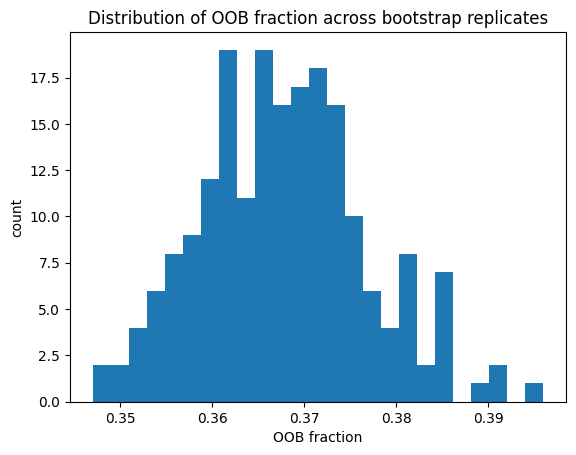

In [3]:
n = 1000
B = 200
rng = np.random.default_rng(RANDOM_STATE)

oob_fracs = []
unique_fracs = []

for _ in range(B):
    idx = rng.integers(low=0, high=n, size=n)  # bootstrap indices
    unique_fracs.append(len(np.unique(idx)) / n)
    mask = np.ones(n, dtype=bool)
    mask[idx] = False
    oob_fracs.append(mask.mean())

print("Average unique fraction:", float(np.mean(unique_fracs)))
print("Average OOB fraction:", float(np.mean(oob_fracs)))
print("Theoretical OOB ~ exp(-1) =", float(np.exp(-1)))

plt.figure()
plt.hist(oob_fracs, bins=25)
plt.title("Distribution of OOB fraction across bootstrap replicates")
plt.xlabel("OOB fraction")
plt.ylabel("count")
plt.show()


## ۶) مثال A (طبقه‌بندی): بگینگ در برابر یک درخت روی Iris

با یک دیتاست کوچک و تمیز (**iris**) شروع می‌کنیم تا مقایسه کنیم:

1. یک درخت تصمیم منفرد
2. یک ensemble بگ‌شده از درخت‌ها (Bootstrap Aggregation)

معیار ارزیابی: accuracy و همچنین بررسی پایداری با چند بار تکرار train/test split.

مسیر دیتاست (ساختار ریپو):
`../../../Datasets/Classification/iris.csv`


,sepal_length,sepal_width,petal_length,petal_width,classification
0,5.4,3.7,1.5,0.2,Iris-setosa
1,4.8,3.4,1.6,0.2,Iris-setosa
2,4.8,3.0,1.4,0.1,Iris-setosa
3,4.3,3.0,1.1,0.1,Iris-setosa
4,5.8,4.0,1.2,0.2,Iris-setosa


shape: (150, 5)
target value counts:


classification
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

Single Tree | accuracy=0.9474 | f1_weighted=0.9472
confusion matrix (rows=true, cols=pred):


,Iris-setosa,Iris-versicolor,Iris-virginica
Iris-setosa,13,0,0
Iris-versicolor,0,11,2
Iris-virginica,0,0,12


Bagging (Trees) | accuracy=0.9737 | f1_weighted=0.9737
confusion matrix (rows=true, cols=pred):


,Iris-setosa,Iris-versicolor,Iris-virginica
Iris-setosa,13,0,0
Iris-versicolor,0,12,1
Iris-virginica,0,0,12


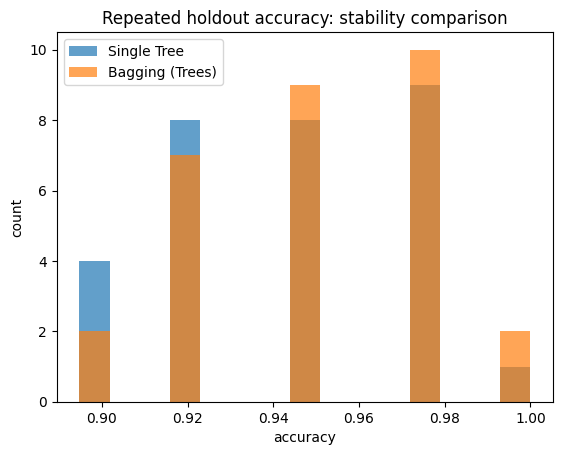

Single Tree: mean= 0.9429824561403509 std= 0.028894156301755455
Bagging:     mean= 0.95 std= 0.027474490812922518


In [4]:
iris_path = "../../../Datasets/Classification/iris.csv"
df_iris = load_csv(iris_path)
print_basic_info(df_iris, target_col="classification")

X = df_iris.drop(columns=["classification"])
y = df_iris["classification"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

tree = DecisionTreeClassifier(random_state=RANDOM_STATE)
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    n_estimators=300,
    bootstrap=True,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

tree.fit(X_train, y_train)
bag.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)
y_pred_bag = bag.predict(X_test)

evaluate_classifier(y_test, y_pred_tree, title="Single Tree")
evaluate_classifier(y_test, y_pred_bag, title="Bagging (Trees)")

# Quick stability check: repeat splitting multiple times
def repeated_holdout_scores(model, X, y, repeats=30, test_size=0.25):
    scores = []
    rng = np.random.default_rng(RANDOM_STATE)
    for r in range(repeats):
        rs = int(rng.integers(0, 10_000_000))
        X_tr, X_te, y_tr, y_te = train_test_split(
            X, y, test_size=test_size, random_state=rs, stratify=y
        )
        model.fit(X_tr, y_tr)
        scores.append(accuracy_score(y_te, model.predict(X_te)))
    return np.array(scores)

scores_tree = repeated_holdout_scores(DecisionTreeClassifier(random_state=RANDOM_STATE), X, y)
scores_bag = repeated_holdout_scores(bag, X, y)

plt.figure()
plt.hist(scores_tree, bins=15, alpha=0.7, label="Single Tree")
plt.hist(scores_bag, bins=15, alpha=0.7, label="Bagging (Trees)")
plt.title("Repeated holdout accuracy: stability comparison")
plt.xlabel("accuracy")
plt.ylabel("count")
plt.legend()
plt.show()

print("Single Tree: mean=", scores_tree.mean(), "std=", scores_tree.std())
print("Bagging:     mean=", scores_bag.mean(), "std=", scores_bag.std())


### به چه چیز توجه کنیم؟

- بگینگ اغلب میانگین accuracy را هم بهتر می‌کند (ولی تضمینی نیست). اثر پایدارتر، **کاهش واریانس** در تکرارهای مختلف است.
- یک درخت منفرد می‌تواند بسته به split تغییرات زیادی داشته باشد. بگینگ این نوسان را کم می‌کند.

این دقیقاً با فرمول ما سازگار است:
$$
\operatorname{Var}[\hat f_{\text{bag}}(x)] = \rho\sigma^2 + \frac{1-\rho}{B}\sigma^2.
$$

زیاد کردن `n_estimators=B` جملهٔ $(1-\rho)\sigma^2/B$ را کم می‌کند، اما جملهٔ $\rho\sigma^2$ باقی می‌ماند. بنابراین برای بهبود بیشتر باید $\rho$ را هم کم کرد (ایدهٔ Random Forest).


## ۷) مثال B (طبقه‌بندی): Random Forest روی Diabetes (با ROC-AUC)

حالا به یک دیتاست جدولی بزرگ‌تر می‌رویم: `diabetes.csv`.

مسیر:
`../../../Datasets/Classification/diabetes.csv`

ستون هدف: `classification`

کارهایی که انجام می‌دهیم:
- ساخت RandomForestClassifier
- استفاده از امتیاز OOB (در صورت فعال بودن)
- محاسبهٔ ROC-AUC (دودویی)
- بررسی کالیبراسیون (اختیاری)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,classification
0,6,148,72,35,0,33.6,0.627,50,Diabetic
1,1,85,66,29,0,26.6,0.351,31,Non-Diabetic
2,8,183,64,0,0,23.3,0.672,32,Diabetic
3,1,89,66,23,94,28.1,0.167,21,Non-Diabetic
4,0,137,40,35,168,43.1,2.288,33,Diabetic


shape: (768, 9)
target value counts:


classification
Non-Diabetic    500
Diabetic        268
Name: count, dtype: int64

OOB score (approx. generalization): 0.7482638888888888
Random Forest (Diabetes) | accuracy=0.7812 | f1_weighted=0.7743
Random Forest (Diabetes) | roc_auc=0.8373
confusion matrix (rows=true, cols=pred):


,0,1
0,111,14
1,28,39


<Figure size 640x480 with 0 Axes>

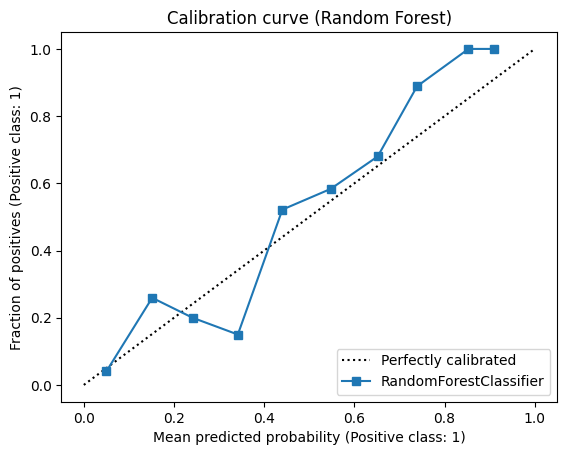

In [5]:
diabetes_path = "../../../Datasets/Classification/diabetes.csv"
df_diab = load_csv(diabetes_path)
print_basic_info(df_diab, target_col="classification")

X = df_diab.drop(columns=["classification"])
y = df_diab["classification"]

# Map to binary 0/1 for ROC-AUC if needed
if y.dtype == "object":
    y_str = y.astype(str).str.strip().str.lower()
    # IMPORTANT: avoid substring matching because 'Non-Diabetic' contains 'Diabetic'
    y_bin = y_str.str.startswith("diab").astype(int)
else:
    y_bin = y

X_train, X_test, y_train, y_test = train_test_split(
    X, y_bin, test_size=0.25, random_state=RANDOM_STATE, stratify=y_bin
)

rf = RandomForestClassifier(
    n_estimators=600,
    max_features="sqrt",
    min_samples_leaf=2,
    oob_score=True,
    bootstrap=True,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

rf.fit(X_train, y_train)

print("OOB score (approx. generalization):", getattr(rf, "oob_score_", None))

y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)

evaluate_classifier(y_test, y_pred, y_proba=y_proba, title="Random Forest (Diabetes)", labels=[0, 1])

# Calibration curve (note: RF probabilities can be miscalibrated)
# Only valid for binary classification with two classes present.
if hasattr(rf, "classes_") and len(rf.classes_) == 2 and len(np.unique(y_test)) == 2:
    plt.figure()
    CalibrationDisplay.from_estimator(rf, X_test, y_test, n_bins=10)
    plt.title("Calibration curve (Random Forest)")
    plt.show()
else:
    print("Skip calibration plot: need a binary problem with two classes in y_test and estimator.classes_.")


## ۸) OOB در برابر CV: چه زمانی به OOB اعتماد کنیم؟

OOB جذاب است چون وقتی بوت‌استرپ دارید، «خودبه‌خود» به دست می‌آید. اما باید نقش آماری آن را دقیق بدانید.

### ۸.۱) OOB چه چیزی را تخمین می‌زند؟

OOB برای هر نمونه فقط از درخت‌هایی استفاده می‌کند که آن نمونه را ندیده‌اند. بنابراین نوعی خطای شبیه اعتبارسنجی متقابل را تقریب می‌زند، بدون اینکه کل ensemble را چندبار از نو آموزش دهید.

### ۸.۲) کجا OOB می‌تواند گمراه‌کننده باشد؟

- اگر `bootstrap=False` باشد، OOB تعریف نمی‌شود.
- اگر داده ساختار گروهی/زمانی داشته باشد (entity leakage)، OOB جایگزین امنی برای splitهای group/time نیست.
- اگر مهندسی ویژگی بیرون از پایپ‌لاین انجام شود (leakage)، OOB می‌تواند خوش‌بینانه شود.
- اگر دیتاست خیلی کوچک باشد، واریانس OOB زیاد می‌شود.

یک رویکرد خوب:
- از OOB برای sweep سریع ابرپارامترها و sanity-check استفاده کنید.
- برای انتخاب و گزارش نهایی از CV یا یک تست‌ست تمیز استفاده کنید.


## ۹) مثال C (رگرسیون): BaggingRegressor روی House Prices

بگینگ فقط مخصوص طبقه‌بندی نیست. در رگرسیون، میانگین‌گیری بسیار طبیعی است.

از دیتاست `house-prices.csv` استفاده می‌کنیم (رگرسیون جدولی).

مسیر:
`../../../Datasets/Regression/house-prices.csv`

ستون هدف: `Price`

مقایسه:
- یک درخت رگرسیون منفرد
- BaggingRegressor (درخت‌ها)


,Home,Price,SqFt,Bedrooms,Bathrooms,Offers,Brick,Neighborhood
0,1,114300,1790,2,2,2,No,East
1,2,114200,2030,4,2,3,No,East
2,3,114800,1740,3,2,1,No,East
3,4,94700,1980,3,2,3,No,East
4,5,119800,2130,3,3,3,No,East


shape: (128, 8)
target value counts:


Price
103200    2
105600    2
117800    2
129800    2
125700    2
114600    1
119800    1
94700     1
114300    1
114200    1
114800    1
123000    1
102600    1
126300    1
176800    1
145800    1
147100    1
83600     1
111400    1
167200    1
Name: count, dtype: int64

Single Tree Regressor | MAE=16121.8750 | RMSE=19248.4009 | R2=0.4324
BaggingRegressor (Trees) | MAE=10767.3516 | RMSE=13239.1995 | R2=0.7315


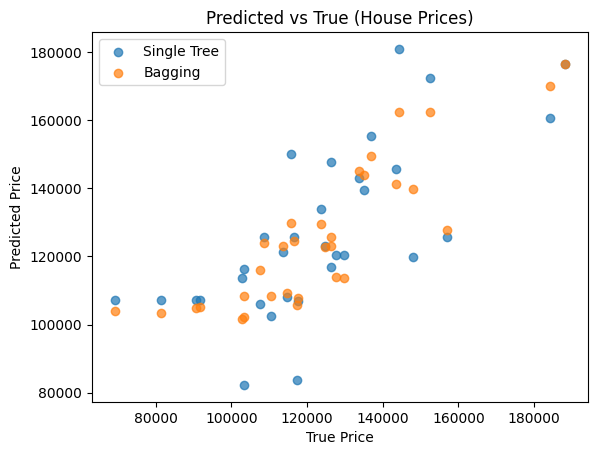

In [6]:
house_path = "../../../Datasets/Regression/house-prices.csv"
df_house = load_csv(house_path)
print_basic_info(df_house, target_col="Price")

X = df_house.drop(columns=["Price"])
y = df_house["Price"]

# Identify categorical vs numeric columns
cat_cols = [c for c in X.columns if X[c].dtype == "object"]
num_cols = [c for c in X.columns if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
    ],
    remainder="drop"
)

tree_reg = Pipeline([
    ("prep", preprocess),
    ("model", DecisionTreeRegressor(random_state=RANDOM_STATE))
])

bag_reg = Pipeline([
    ("prep", preprocess),
    ("model", BaggingRegressor(
        estimator=DecisionTreeRegressor(random_state=RANDOM_STATE),
        n_estimators=400,
        bootstrap=True,
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE
)

tree_reg.fit(X_train, y_train)
bag_reg.fit(X_train, y_train)

pred_tree = tree_reg.predict(X_test)
pred_bag = bag_reg.predict(X_test)

evaluate_regressor(y_test, pred_tree, title="Single Tree Regressor")
evaluate_regressor(y_test, pred_bag, title="BaggingRegressor (Trees)")

plt.figure()
plt.scatter(y_test, pred_tree, alpha=0.7, label="Single Tree")
plt.scatter(y_test, pred_bag, alpha=0.7, label="Bagging")
plt.title("Predicted vs True (House Prices)")
plt.xlabel("True Price")
plt.ylabel("Predicted Price")
plt.legend()
plt.show()


## ۱۰) مثال D (رگرسیون): RandomForestRegressor روی Diamonds

رگرسیون جدولیِ واقعی معمولاً متغیرهای دسته‌ای هم دارد.
از دیتاست `diamonds.csv` استفاده می‌کنیم که ستون‌های دسته‌ای مثل `cut`، `color`، `clarity` دارد.

مسیر:
`../../../Datasets/Regression/diamonds.csv`

هدف: `price`

کارها:
- ساخت پایپ‌لاین پیش‌پردازش (impute + one-hot)
- آموزش RandomForestRegressor
- مقایسه با یک درخت
- بررسی permutation importance


,id,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


shape: (53940, 11)
target value counts:


price
605     132
802     127
625     126
828     125
776     124
698     121
789     121
544     120
666     114
552     113
596     107
720     107
645     104
526     101
675      99
1013     98
844      98
765      95
684      91
561      91
Name: count, dtype: int64

Single Tree (Diamonds) | MAE=362.2722 | RMSE=745.1628 | R2=0.9651
RandomForestRegressor (Diamonds) | MAE=294.5712 | RMSE=588.4933 | R2=0.9782


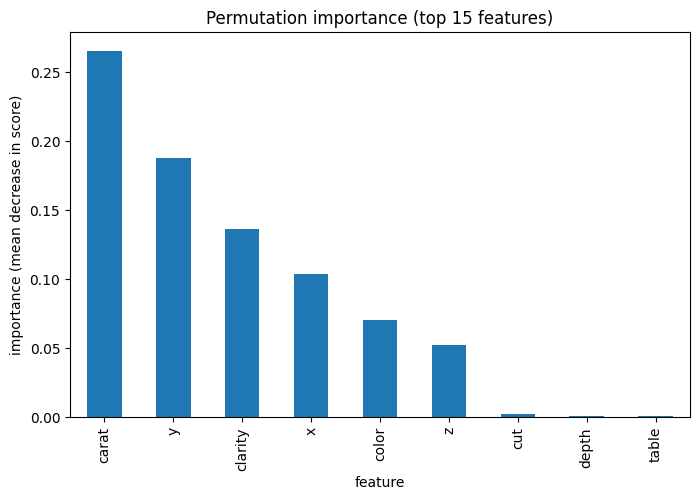

In [7]:
diamonds_path = "../../../Datasets/Regression/diamonds.csv"
df_diam = load_csv(diamonds_path)
print_basic_info(df_diam, target_col="price")

# Some versions have an 'id' column; drop if present
drop_cols = [c for c in ["id"] if c in df_diam.columns]

X = df_diam.drop(columns=drop_cols + ["price"])
y = df_diam["price"]

cat_cols = [c for c in X.columns if X[c].dtype == "object"]
num_cols = [c for c in X.columns if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
    ]
)

tree = Pipeline([
    ("prep", preprocess),
    ("model", DecisionTreeRegressor(random_state=RANDOM_STATE))
])

rf = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestRegressor(
        n_estimators=500,
        max_features="sqrt",
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE
)

tree.fit(X_train, y_train)
rf.fit(X_train, y_train)

pred_tree = tree.predict(X_test)
pred_rf = rf.predict(X_test)

evaluate_regressor(y_test, pred_tree, title="Single Tree (Diamonds)")
evaluate_regressor(y_test, pred_rf, title="RandomForestRegressor (Diamonds)")

# Permutation importance (model-agnostic) on the test set
# Note: this can be slow on very large datasets; sample if needed.
X_test_sample = X_test.sample(n=min(3000, len(X_test)), random_state=RANDOM_STATE)
y_test_sample = y_test.loc[X_test_sample.index]

result = permutation_importance(
    rf, X_test_sample, y_test_sample,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

importances = pd.Series(result.importances_mean, index=X_test_sample.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
importances.head(15).plot(kind="bar")
plt.title("Permutation importance (top 15 features)")
plt.xlabel("feature")
plt.ylabel("importance (mean decrease in score)")
plt.show()


## ۱۱) تنظیم ابرپارامتر (با پروتکل آماری درست)

Random Forest ابرپارامترهای زیادی دارد و اگر بی‌دقت تنظیم کنیم، به leakage و نتایج خوش‌بینانه می‌رسیم.
یک روش سبک و قابل اتکا:

1. پایپ‌لاین بسازید (پیش‌پردازش داخل CV باشد)
2. از **RandomizedSearchCV** با اعتبارسنجی متقابل استفاده کنید
3. یک تست‌ست تمیز برای ارزیابی نهایی نگه دارید

در اینجا یک RandomForestClassifier را روی دیتاست `drug200.csv` تنظیم می‌کنیم چون متغیرهای دسته‌ای دارد و اهمیت پایپ‌لاین در CV را خوب نشان می‌دهد.

مسیر:
`../../../Datasets/Classification/drug200.csv`
هدف: `Drug`


In [8]:
drug_path = "../../../Datasets/Classification/drug200.csv"
df_drug = load_csv(drug_path)
print_basic_info(df_drug, target_col="Drug")

X = df_drug.drop(columns=["Drug"])
y = df_drug["Drug"]

cat_cols = [c for c in X.columns if X[c].dtype == "object"]
num_cols = [c for c in X.columns if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
    ]
)

rf_clf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)

pipe = Pipeline([
    ("prep", preprocess),
    ("model", rf_clf)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

param_dist = {
    "model__n_estimators": [200, 400, 800],
    "model__max_depth": [None, 4, 8, 12, 20],
    "model__min_samples_leaf": [1, 2, 5, 10],
    "model__max_features": ["sqrt", "log2", 0.5, 0.8],
    "model__bootstrap": [True],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

search = RandomizedSearchCV(
    pipe,
    param_distributions=param_dist,
    n_iter=25,
    scoring="accuracy",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print("Best CV score:", search.best_score_)
print("Best params:")
display(search.best_params_)

best_model = search.best_estimator_
y_pred = best_model.predict(X_test)
evaluate_classifier(y_test, y_pred, title="Tuned RF (Drug200)")


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


shape: (200, 6)
target value counts:


Drug
DrugY    91
drugX    54
drugA    23
drugC    16
drugB    16
Name: count, dtype: int64

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best CV score: 0.9933333333333334
Best params:


{'model__n_estimators': 800,
 'model__min_samples_leaf': 5,
 'model__max_features': 0.5,
 'model__max_depth': 4,
 'model__bootstrap': True}

Tuned RF (Drug200) | accuracy=0.9800 | f1_weighted=0.9798
confusion matrix (rows=true, cols=pred):


,DrugY,drugA,drugB,drugC,drugX
DrugY,23,0,0,0,0
drugA,0,6,0,0,0
drugB,0,0,4,0,0
drugC,0,0,0,4,0
drugX,1,0,0,0,12


## ۱۲) اهمیت ویژگی‌ها: چه چیزی را می‌شود اعتماد کرد و چه چیزی را نه

Random Forest یک اهمیت ویژگی ساده (`feature_importances_`) می‌دهد، اما باید با احتیاط استفاده شود:

- این معیار مبتنی بر **ناخالصی** است (کاهش میانگین ناخالصی) و ممکن است سوگیری داشته باشد به سمت:
  - ویژگی‌های دسته‌ای با تعداد سطوح زیاد (بسته به نحوهٔ کدگذاری)
  - ویژگی‌های پیوسته با نقاط split زیاد
- در حضور هم‌خطی (multicollinearity)، اهمیت می‌تواند ناپایدار شود و بین ویژگی‌های هم‌بسته تقسیم یا تصادفی توزیع شود.

گزینهٔ قابل‌اتکاتر **Permutation importance** است:
- یک ویژگی را در دادهٔ اعتبارسنجی shuffle می‌کنیم
- افت امتیاز را اندازه می‌گیریم

Permutation importance هم کامل نیست (ویژگی‌های هم‌بسته می‌توانند همدیگر را پوشش دهند)، اما به مفهوم «وابستگی پیش‌بینی به ویژگی» نزدیک‌تر است.

در مثال Diamonds قبلاً permutation importance را محاسبه کردیم.
اگر می‌خواهید اهمیت **گروهی** برای ویژگی‌های one-hot داشته باشید (پیشنهاد می‌شود)، ستون‌ها را بر اساس نام ویژگی اصلی گروه‌بندی و اهمیت را جمع/میانگین کنید.


## ۱۳) خطاهای رایج و بهترین روش‌ها

### ۱۳.۱) Leakage همچنان خطرناک است

بگینگ و Random Forest معجزه نیستند. اگر اطلاعات نشت کند (مثلاً leakage هدف، ویژگی‌های پس از وقوع، یا پیش‌پردازش روی کل داده)، مدل از آن سوءاستفاده می‌کند.

**قاعده:** پیش‌پردازش را داخل `Pipeline` قرار دهید و ارزیابی را درست انجام دهید.

### ۱۳.۲) بگینگ برای یادگیرنده‌های ناپایدار بهترین است

بگینگ بیشترین سود را برای مدل‌های واریانس‌بالا دارد که با تغییر نمونهٔ آموزش زیاد تغییر می‌کنند.
درخت تصمیم مثال کلاسیک است.
مدل‌های خطی معمولاً پایدارترند؛ بگینگ آن‌ها اغلب سود کمتری دارد.

### ۱۳.۳) `n_estimators` را با بازده نزولی انتخاب کنید

خطا معمولاً ابتدا سریع کم می‌شود و بعد تخت می‌شود.
یک روش عملی: `n_estimators` را آنقدر زیاد کنید تا عملکرد OOB/CV پایدار شود و زمان اجرا عامل محدودکننده گردد.

### ۱۳.۴) بازتولیدپذیری

- تا حد ممکن `random_state` را تنظیم کنید.
- توجه: آموزش موازی (`n_jobs=-1`) ممکن است بسته به BLAS/سیستم عامل کمی غیرقطعی باشد، ولی معمولاً نتایج پایدار است.

### ۱۳.۵) زمانی که RF کافی نیست

RF می‌تواند در این موارد ضعیف‌تر باشد:
- ویژگی‌های متنی بسیار پراکنده و پُربعد (مدل‌های خطی بهتر می‌شوند)
- برون‌یابی در رگرسیون (درخت‌ها قطعه‌ای-ثابت هستند)
- سیگنال‌های هموار و جمع‌پذیر قوی (GBDTها اغلب بهترند)


## ۲.۵) تجزیهٔ بایاس–واریانس و اینکه بگینگ دقیقاً چه چیزی را تغییر می‌دهد

در رگرسیون با خطای مربعی، یکی از هویت‌های بسیار مهم، تجزیهٔ بایاس–واریانس است.

فرض کنید داده از مدل زیر پیروی می‌کند:
$$
Y = f^*(X) + \varepsilon,\quad \mathbb{E}[\varepsilon\mid X]=0,\quad \operatorname{Var}(\varepsilon\mid X)=\sigma_\varepsilon^2.
$$

$\hat f(x)$ پیش‌بینی است که از یک مجموعه‌دادهٔ آموزشی تصادفی (و شاید تصادفی‌بودن الگوریتم) یاد گرفته می‌شود. برای $x$ ثابت، MSE مورد انتظار روی تست (با شرط $X=x$) را در نظر بگیرید:
$$
\mathbb{E}\big[(Y-\hat f(x))^2 \mid X=x\big].
$$

با جایگذاری $Y=f^*(x)+\varepsilon$:
$$
\mathbb{E}\big[(f^*(x)+\varepsilon-\hat f(x))^2\big]
= \mathbb{E}\big[(f^*(x)-\hat f(x))^2\big] + \mathbb{E}[\varepsilon^2]
$$
چون جملهٔ ضربی صفر می‌شود:
$$
\mathbb{E}\big[\varepsilon(f^*(x)-\hat f(x))\big]=\mathbb{E}\big[\mathbb{E}[\varepsilon\mid X=x]\,(f^*(x)-\hat f(x))\big]=0.
$$

اکنون جملهٔ اول را حول میانگین پیش‌بین $\bar f(x)=\mathbb{E}[\hat f(x)]$ باز می‌کنیم:
$$
\mathbb{E}\big[(f^*(x)-\hat f(x))^2\big]
= \big(f^*(x)-\bar f(x)\big)^2 + \mathbb{E}\big[(\hat f(x)-\bar f(x))^2\big].
$$

پس:
$$
\mathbb{E}\big[(Y-\hat f(x))^2\mid X=x\big]
= \sigma_\varepsilon^2 + \underbrace{\big(\text{Bias}[\hat f(x)]\big)^2}_{(f^*(x)-\bar f(x))^2}
+ \underbrace{\operatorname{Var}[\hat f(x)]}_{\mathbb{E}[(\hat f(x)-\bar f(x))^2]}.
$$

### بگینگ چه چیزی را تغییر می‌دهد؟

بگینگ عمدتاً جملهٔ **واریانس** را هدف می‌گیرد، چون میانگین‌گیری از چند پیش‌بین واریانس را کاهش می‌دهد. در مدل ایده‌آلِ یادگیرنده‌های هم‌بسته:
$$
\operatorname{Var}[\hat f_{\text{bag}}(x)] = \rho\sigma^2 + \frac{1-\rho}{B}\sigma^2,
$$
پس با افزایش $B$ و همچنین با کاهش هم‌بستگی $\rho$ (مکانیزم Random Forest) واریانس کم می‌شود.

### آیا بگینگ بایاس را هم کم می‌کند؟

در رگرسیون با میانگین‌گیری خطی، بایاس معمولاً نزدیک به بایاس مدل پایه است، پس داستان اصلی کاهش بایاس نیست.
اما در طبقه‌بندی، قاعدهٔ تجمیع **غیرخطی** است (argmax روی میانگین احتمال‌ها / رأی اکثریت)، بنابراین در برخی حالت‌ها بایاس هم می‌تواند بهتر شود. شهود: رأی‌گیری می‌تواند مرز تصمیم را به مرز بیز نزدیک‌تر کند وقتی مدل پایه ناپایدار باشد.

### دیدگاه بگینگ بی‌نهایت (Monte Carlo)

بگینگ با $B$ تکرار بوت‌استرپ یک تقریب مونت‌کارلو از یک امیدریاضی است:
$$
f_{\infty}(x)=\mathbb{E}_{D^{\*}}\big[\hat f_{D^{\*}}(x)\big],
\quad
\hat f_{\text{bag}}(x)=\frac{1}{B}\sum_{b=1}^B \hat f^{(b)}(x)\approx f_{\infty}(x).
$$

طبق قانون اعداد بزرگ، وقتی $B\to\infty$، $\hat f_{\text{bag}}(x)\to f_{\infty}(x)$ (برای دادهٔ آموزشی ثابت و مکانیزم بوت‌استرپ). در عمل یعنی: وقتی $B$ «به اندازهٔ کافی بزرگ» شد، اضافه کردن درخت بیشتر عمدتاً نویز مونت‌کارلو را کم می‌کند، نه خطای ساختاری را.


## ۴.۴) معیارهای split در درخت‌ها و ارتباطشان با بگینگ (مرور سریع)

چون Random Forest از درخت‌های سبک CART ساخته می‌شود، بد نیست یادمان باشد درخت در هر split چه چیزی را به‌صورت محلی بهینه می‌کند.

### ناخالصی‌های طبقه‌بندی

در یک گره، فرض کنید نسبت کلاس‌ها $p_1,\dots,p_K$ است.
دو معیار رایج ناخالصی:

- **Gini impurity:**
$$
G = 1-\sum_{k=1}^K p_k^2.
$$

- **Entropy:**
$$
H = -\sum_{k=1}^K p_k\log p_k.
$$

یک split طوری انتخاب می‌شود که کاهش ناخالصی بیشینه شود:
$$
\Delta I = I(\text{parent}) - \left(\frac{n_L}{n}I(L) + \frac{n_R}{n}I(R)\right).
$$

### معیار رگرسیون

در رگرسیون، CART معمولاً کاهش واریانس/کاهش MSE را استفاده می‌کند.
واریانس گره:
$$
\operatorname{Var}(Y) = \frac{1}{n}\sum_{i=1}^n (y_i-\bar y)^2.
$$

split کاهش واریانس درون‌گرهی را بیشینه می‌کند.

### چرا این برای ensemble مهم است؟

- درخت‌های خیلی عمیق می‌توانند ناخالصی/واریانس را روی آموزش تقریباً صفر کنند (overfit) و واریانس بالایی نسبت به تغییر داده داشته باشند.
- بگینگ/RF با میانگین‌گیری از تعداد زیادی از همین درخت‌های واریانس‌بالا، تعمیم قوی‌تری می‌سازد.
- محدودیت ویژگی‌های تصادفی در RF باعث می‌شود یک ویژگی غالب همیشه «برندهٔ مسابقهٔ ناخالصی» در splitهای بالایی نباشد (کاهش هم‌بستگی).


## ۸.۳) منحنی یادگیری OOB: چند درخت کافی است؟

یک روش عملی برای انتخاب `n_estimators` این است که عملکرد OOB را بر حسب تعداد درخت‌ها رسم کنیم.
این کار را می‌توان با `warm_start=True` به‌صورت افزایشی انجام داد.

این منحنی را روی `diabetes.csv` (طبقه‌بندی دودویی) رسم می‌کنیم تا ببینیم امتیاز OOB چگونه پایدار می‌شود.


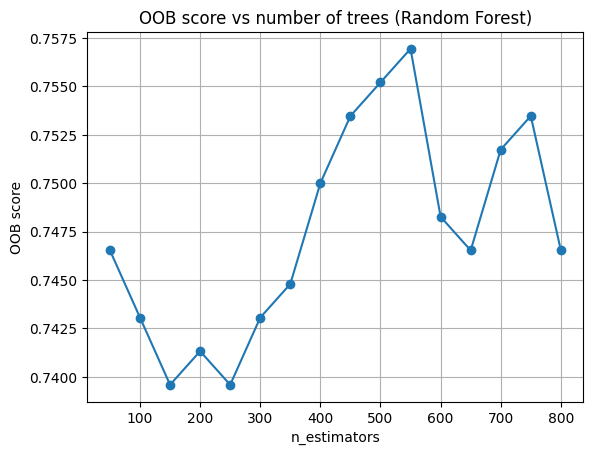

In [9]:
# OOB learning curve with warm_start
diabetes_path = "../../../Datasets/Classification/diabetes.csv"
df_diab = load_csv(diabetes_path)

X = df_diab.drop(columns=["classification"])
y = df_diab["classification"]

y_str = y.astype(str).str.strip().str.lower()
y_bin = y_str.str.startswith("diab").astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_bin, test_size=0.25, random_state=RANDOM_STATE, stratify=y_bin
)

rf_ws = RandomForestClassifier(
    n_estimators=50,
    warm_start=True,
    oob_score=True,
    bootstrap=True,
    max_features="sqrt",
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

oob_scores = []
tree_grid = list(range(50, 801, 50))
for n_trees in tree_grid:
    rf_ws.set_params(n_estimators=n_trees)
    rf_ws.fit(X_train, y_train)
    oob_scores.append(rf_ws.oob_score_)

plt.figure()
plt.plot(tree_grid, oob_scores, marker="o")
plt.title("OOB score vs number of trees (Random Forest)")
plt.xlabel("n_estimators")
plt.ylabel("OOB score")
plt.grid(True)
plt.show()


## ۱۵) مثال E (چندکلاسه): Random Forest روی Wine Quality

دیتاست `Wine_Quality.csv` یک امتیاز `quality` دارد (معمولاً 3 تا 9). می‌توان آن را به شکل‌های مختلف مدل کرد:

- **طبقه‌بندی چندکلاسه**: پیش‌بینی مقدار گسستهٔ کیفیت
- **ترتیبی / رگرسیون**: برخورد عددی با کیفیت

در این درس تمرکز ما طبقه‌بندی بگینگ/RF است. یک هدف **۳ کلاسه** می‌سازیم:
- `low`: کیفیت <= 5
- `mid`: کیفیت == 6
- `high`: کیفیت >= 7

مسیر:
`../../../Datasets/Classification/Wine_Quality.csv`


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


shape: (4898, 12)
target value counts:


quality
6    2198
5    1457
7     880
8     175
4     163
3      20
9       5
Name: count, dtype: int64

Random Forest (Wine Quality 3-class) | accuracy=0.7208 | f1_weighted=0.7197
confusion matrix (rows=true, cols=pred):


,high,low,mid
high,157,6,102
low,7,297,106
mid,38,83,429


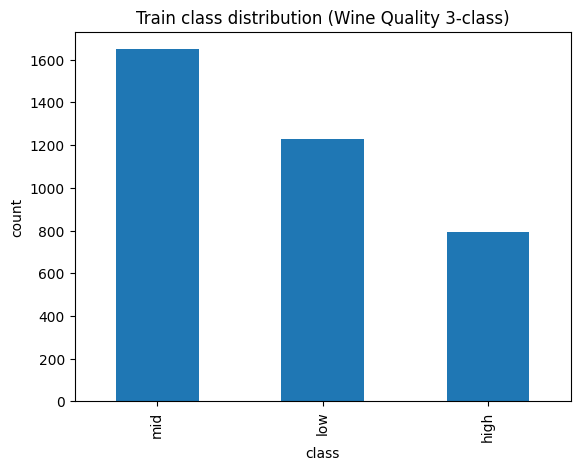

In [10]:
wine_path = "../../../Datasets/Classification/Wine_Quality.csv"
df_wine = load_csv(wine_path)
print_basic_info(df_wine, target_col="quality")

X = df_wine.drop(columns=["quality"])
y_raw = df_wine["quality"]

def to_3class(q):
    if q <= 5:
        return "low"
    elif q == 6:
        return "mid"
    else:
        return "high"

y = y_raw.apply(to_3class)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=800,
    max_features="sqrt",
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

evaluate_classifier(y_test, y_pred, title="Random Forest (Wine Quality 3-class)")

# Class distribution
plt.figure()
pd.Series(y_train).value_counts().plot(kind="bar")
plt.title("Train class distribution (Wine Quality 3-class)")
plt.xlabel("class")
plt.ylabel("count")
plt.show()


## ۱۶) مثال F (رگرسیون): Random Forest روی European Ski Resorts

برای اینکه نشان دهیم بگینگ/RF ابزارهای عمومی برای دادهٔ جدولی هستند، یک مثال رگرسیون دیگر هم می‌زنیم.

دیتاست:
`../../../Datasets/Regression/European_Ski_Resorts.csv`

هدف: پیش‌بینی `DayPassPriceAdult` از ترکیبی از ویژگی‌های عددی و دسته‌ای.
این دیتاست معمولاً فیلدهای Yes/No و نام کشور دارد، پس به one-hot نیاز داریم.

همچنین K-fold CV را نشان می‌دهیم تا برآوردی پایدارتر از یک split منفرد داشته باشیم.


In [11]:
ski_path = "../../../Datasets/Regression/European_Ski_Resorts.csv"
df_ski = load_csv(ski_path)

target = "DayPassPriceAdult"
# Some CSV exports include an unnamed first column; drop if needed
unnamed = [c for c in df_ski.columns if str(c).startswith("Unnamed")]
df_ski = df_ski.drop(columns=unnamed, errors="ignore")

# Keep rows where target is present and numeric
df_ski = df_ski.dropna(subset=[target]).copy()

X = df_ski.drop(columns=[target])
y = pd.to_numeric(df_ski[target], errors="coerce")
mask = y.notna()
X = X.loc[mask]
y = y.loc[mask]

cat_cols = [c for c in X.columns if X[c].dtype == "object"]
num_cols = [c for c in X.columns if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
    ]
)

rf_reg = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestRegressor(
        n_estimators=700,
        max_features="sqrt",
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

# K-fold CV RMSE
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
neg_rmse = cross_val_score(
    rf_reg, X, y,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1
)
rmse = -neg_rmse
print("CV RMSE mean:", rmse.mean(), "std:", rmse.std())

# Fit a final model on a train/test split for interpretability plots
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE
)
rf_reg.fit(X_train, y_train)
pred = rf_reg.predict(X_test)
evaluate_regressor(y_test, pred, title="RandomForestRegressor (Ski Resorts)")


CV RMSE mean: 9.516889217442564 std: 1.3154640525970591
RandomForestRegressor (Ski Resorts) | MAE=6.9782 | RMSE=9.0160 | R2=0.4716


## ۱۷) از صفر (مفهومی): یک حلقهٔ بگینگ مینیمال

یک‌بار پیاده‌سازی سادهٔ بگینگ کمک می‌کند مکانیزم را واقعاً بفهمید.
در کد زیر:

- یک مدل پایه انتخاب می‌کنیم
- شاخص‌های بوت‌استرپ می‌گیریم
- کپی‌های (clone) مدل را آموزش می‌دهیم
- پیش‌بینی‌ها را میانگین می‌گیریم

این کد جایگزین scikit-learn نیست (scikit-learn بهینه و مقاوم است)، هدف فقط شفاف کردن مکانیزم است.


In [12]:
from sklearn.base import clone

def manual_bagging_regression(base_estimator, X_train, y_train, X_test, B=200, random_state=7):
    rng = np.random.default_rng(random_state)
    n = len(X_train)
    models = []
    for b in range(B):
        idx = rng.integers(0, n, size=n)  # bootstrap indices
        est = clone(base_estimator)
        est.fit(X_train.iloc[idx], y_train.iloc[idx])
        models.append(est)
    preds = np.column_stack([m.predict(X_test) for m in models])
    return preds.mean(axis=1)

# Demo on a subset of house prices (numerical-only) for simplicity
house_path = "../../../Datasets/Regression/house-prices.csv"
df_house = load_csv(house_path)
df_house = df_house.dropna().copy()

# Convert simple Yes/No columns if present (keep it minimal)
for col in df_house.columns:
    if df_house[col].dtype == "object" and set(df_house[col].unique()) <= {"Yes", "No"}:
        df_house[col] = (df_house[col] == "Yes").astype(int)

# Select numeric columns only (toy demo)
y = df_house["Price"]
X = df_house.drop(columns=["Price"])
X = X.select_dtypes(include=[np.number])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE
)

base = DecisionTreeRegressor(random_state=RANDOM_STATE)
base.fit(X_train, y_train)
pred_base = base.predict(X_test)

pred_bag = manual_bagging_regression(base, X_train, y_train, X_test, B=300, random_state=RANDOM_STATE)

evaluate_regressor(y_test, pred_base, title="Manual: Single Tree")
evaluate_regressor(y_test, pred_bag, title="Manual: Bagged Trees")


Manual: Single Tree | MAE=18215.6250 | RMSE=20731.5656 | R2=0.3416
Manual: Bagged Trees | MAE=12650.2083 | RMSE=15272.1918 | R2=0.6427


## ۱۸) نکات محاسباتی (نگاه مهندسی)

### پیچیدگی آموزش (شهود تقریبی)

برای یک درخت تصمیم، هزینهٔ آموزش معمولاً تقریب زده می‌شود:
- $O(n\,d\,\log n)$ (بسته به روش جستجوی split)
که در آن $n$ تعداد نمونه‌ها و $d$ تعداد ویژگی‌هاست.

برای ensemble با $B$ درخت، هزینه تقریباً خطی با $B$ رشد می‌کند:
- $O(B\,n\,d\,\log n)$

Random Forest تعداد ویژگی‌های قابل بررسی در هر split را کم می‌کند (`max_features`) و هم می‌تواند هزینه را کم کند و هم هم‌بستگی را کاهش دهد.

### موازی‌سازی

Ensembleها ذاتاً موازی‌پذیر هستند:
- هر درخت مستقل آموزش می‌بیند.
- scikit-learn با `n_jobs` از چند هستهٔ CPU استفاده می‌کند.

### حافظه

جنگل‌های بزرگ می‌توانند RAM زیادی مصرف کنند:
- هر درخت آستانه‌ها و اندیس ویژگی‌ها و مقادیر برگ‌ها را ذخیره می‌کند.
- اگر `min_samples_leaf` خیلی کوچک باشد و داده نویزی باشد، تعداد برگ‌ها و عمق می‌تواند زیاد شود.

### راهنمای عملی

- از `n_estimators` در حد چندصد شروع کنید و منحنی‌های OOB/CV را ببینید.
- برای دادهٔ نویزی، `min_samples_leaf` را 2 یا 5 امتحان کنید (برگ‌ها پایدارتر می‌شوند).
- برای طبقه‌بندی، `max_features="sqrt"` یک baseline قوی است.
- برای رگرسیون، `max_features=1.0` هم می‌تواند خوب باشد، اما `sqrt` یا کسرهای کوچک‌تر تنوع را بهتر می‌کند.


## ۱۴) تمرین‌ها (پیشنهادی)

1. **OOB در برابر CV:** روی `diabetes.csv` امتیاز OOB را با accuracy در 5-fold CV برای همان ابرپارامترها مقایسه کنید. چقدر نزدیک‌اند؟
2. **آزمایش هم‌بستگی:** روی iris، بگینگ را با `n_estimators={10, 50, 200, 1000}` مقایسه کنید و میانگین/انحراف معیار accuracy در repeated holdout را رسم کنید.
3. **تصادفی‌سازی ویژگی:** روی diabetes، `n_estimators` را ثابت بگیرید و `max_features` را روی `{0.3, 0.5, "sqrt", 1.0}` sweep کنید. رفتار بایاس-واریانس را مشاهده کنید.
4. **Permutation در برابر impurity importance:** برای RF روی house prices (رگرسیون)، اهمیت مبتنی بر ناخالصی را با permutation importance مقایسه کنید. آیا اختلاف دارند؟
5. **چک پایداری:** `random_state` را تغییر دهید و ببینید نتیجه‌گیری‌های شما وابسته به split خوش‌شانس نباشد.


## منابع (برای مطالعهٔ عمیق‌تر)

- Leo Breiman (1996). *Bagging Predictors*. Machine Learning.
- Leo Breiman (2001). *Random Forests*. Machine Learning.
- Hastie, Tibshirani, Friedman (2009/2017). *The Elements of Statistical Learning* (بخش‌های مربوط به بگینگ و Random Forest).
- James, Witten, Hastie, Tibshirani (2021). *An Introduction to Statistical Learning* (فصل‌های ensemble).
